### Compare the 45 models trained (4 Class ANN)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('default')
sns.set_palette("husl")

RESULTS_DIR = Path("results/4_Classes_ANN")
results_csv = RESULTS_DIR / "all_experiments.csv"

df = pd.read_csv(results_csv)
print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

Total experiments: 45
Columns: ['experiment_id', 'architecture', 'hidden1', 'hidden2', 'weight_decay', 'dropout_rate', 'learning_rate', 'mean_accuracy', 'std_accuracy', 'total_epochs', 'training_time_s', 'model_file']

First 5 rows:
   experiment_id architecture  hidden1  hidden2  weight_decay  dropout_rate  \
0              1      1-layer       16      NaN           0.2           0.5   
1              2      1-layer       16      NaN           0.2           0.6   
2              3      1-layer       16      NaN           0.2           0.7   
3              4      1-layer       16      NaN           0.3           0.5   
4              5      1-layer       16      NaN           0.3           0.6   

   learning_rate  mean_accuracy  std_accuracy  total_epochs  training_time_s  \
0        0.00001        0.28125      0.048007          1036         8.715585   
1        0.00001        0.30625      0.040984          1655        11.265880   
2        0.00001        0.29375      0.110926       

In [4]:
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nAccuracy Statistics:")
print(f"  Best:    {df['mean_accuracy'].max()*100:.2f}%")
print(f"  Worst:   {df['mean_accuracy'].min()*100:.2f}%")
print(f"  Mean:    {df['mean_accuracy'].mean()*100:.2f}%")
print(f"  Median:  {df['mean_accuracy'].median()*100:.2f}%")
print(f"  Std Dev: {df['mean_accuracy'].std()*100:.2f}%")

print(f"\nBy Architecture:")
for arch in df['architecture'].unique():
    arch_df = df[df['architecture'] == arch]
    print(f"  {arch}: {arch_df['mean_accuracy'].mean()*100:.2f}% ± {arch_df['mean_accuracy'].std()*100:.2f}% (n={len(arch_df)})")

print(f"\nTraining Time:")
print(f"  Total: {df['training_time_s'].sum()/60:.1f} minutes")
print(f"  Mean per experiment: {df['training_time_s'].mean():.1f} seconds")
print(f"  Median epochs: {df['total_epochs'].median():.0f}")

SUMMARY STATISTICS

Accuracy Statistics:
  Best:    38.75%
  Worst:   18.75%
  Mean:    27.51%
  Median:  27.50%
  Std Dev: 4.71%

By Architecture:
  1-layer: 29.93% ± 3.56% (n=18)
  2-layer: 25.90% ± 4.75% (n=27)

Training Time:
  Total: 7.5 minutes
  Mean per experiment: 10.1 seconds
  Median epochs: 1153


In [ ]:
df_sorted = df.sort_values('mean_accuracy', ascending=False)

print("="*100)
print("TOP 10 MODELS")
print("="*100)
top10 = df_sorted.head(10)[['experiment_id', 'architecture', 'hidden1', 'hidden2', 
                             'weight_decay', 'dropout_rate', 'mean_accuracy', 'std_accuracy']]
print(top10.to_string(index=False))

print("\n" + "="*100)
print("BEST MODEL")
print("="*100)
best = df_sorted.iloc[0]
print(f"  Experiment ID: {best['experiment_id']}")
print(f"  Architecture: {best['architecture']}")
print(f"  Hidden Layers: {best['hidden1']}" + (f" → {best['hidden2']}" if best['hidden2'] != 'None' else ""))
print(f"  Weight Decay: {best['weight_decay']}")
print(f"  Dropout Rate: {best['dropout_rate']}")
print(f"  Mean Accuracy: {best['mean_accuracy']*100:.2f}% ± {best['std_accuracy']*100:.2f}%")
print(f"  Total Epochs: {best['total_epochs']}")
print(f"  Training Time: {best['training_time_s']:.1f}s")
print(f"  Model File: {best['model_file']}")
print("="*100)

TOP 10 MODELS
 experiment_id architecture  hidden1  hidden2  weight_decay  dropout_rate  mean_accuracy  std_accuracy
             6      1-layer       16      NaN           0.3           0.7        0.38750      0.057282
             5      1-layer       16      NaN           0.3           0.6        0.36250      0.041458
            20      2-layer       32     16.0           0.2           0.6        0.34375      0.048007
            23      2-layer       32     16.0           0.3           0.6        0.33125      0.071535
            26      2-layer       32     16.0           0.5           0.6        0.33125      0.062187
            27      2-layer       32     16.0           0.5           0.7        0.33125      0.020729
            13      1-layer        8      NaN           0.3           0.5        0.32500      0.030619
            17      1-layer        8      NaN           0.5           0.6        0.31875      0.044634
            22      2-layer       32     16.0           0.3

C:\Users\duart\AppData\Local\Temp\ipykernel_15040\3341734303.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([df[df['architecture'] == arch]['mean_acc_pct'].values
C:\Users\duart\AppData\Local\Temp\ipykernel_15040\3341734303.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([df[df['weight_decay'] == wd]['mean_acc_pct'].values
C:\Users\duart\AppData\Local\Temp\ipykernel_15040\3341734303.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([df[df['dropout_rate'] == dr]['mean_acc_pct'].values


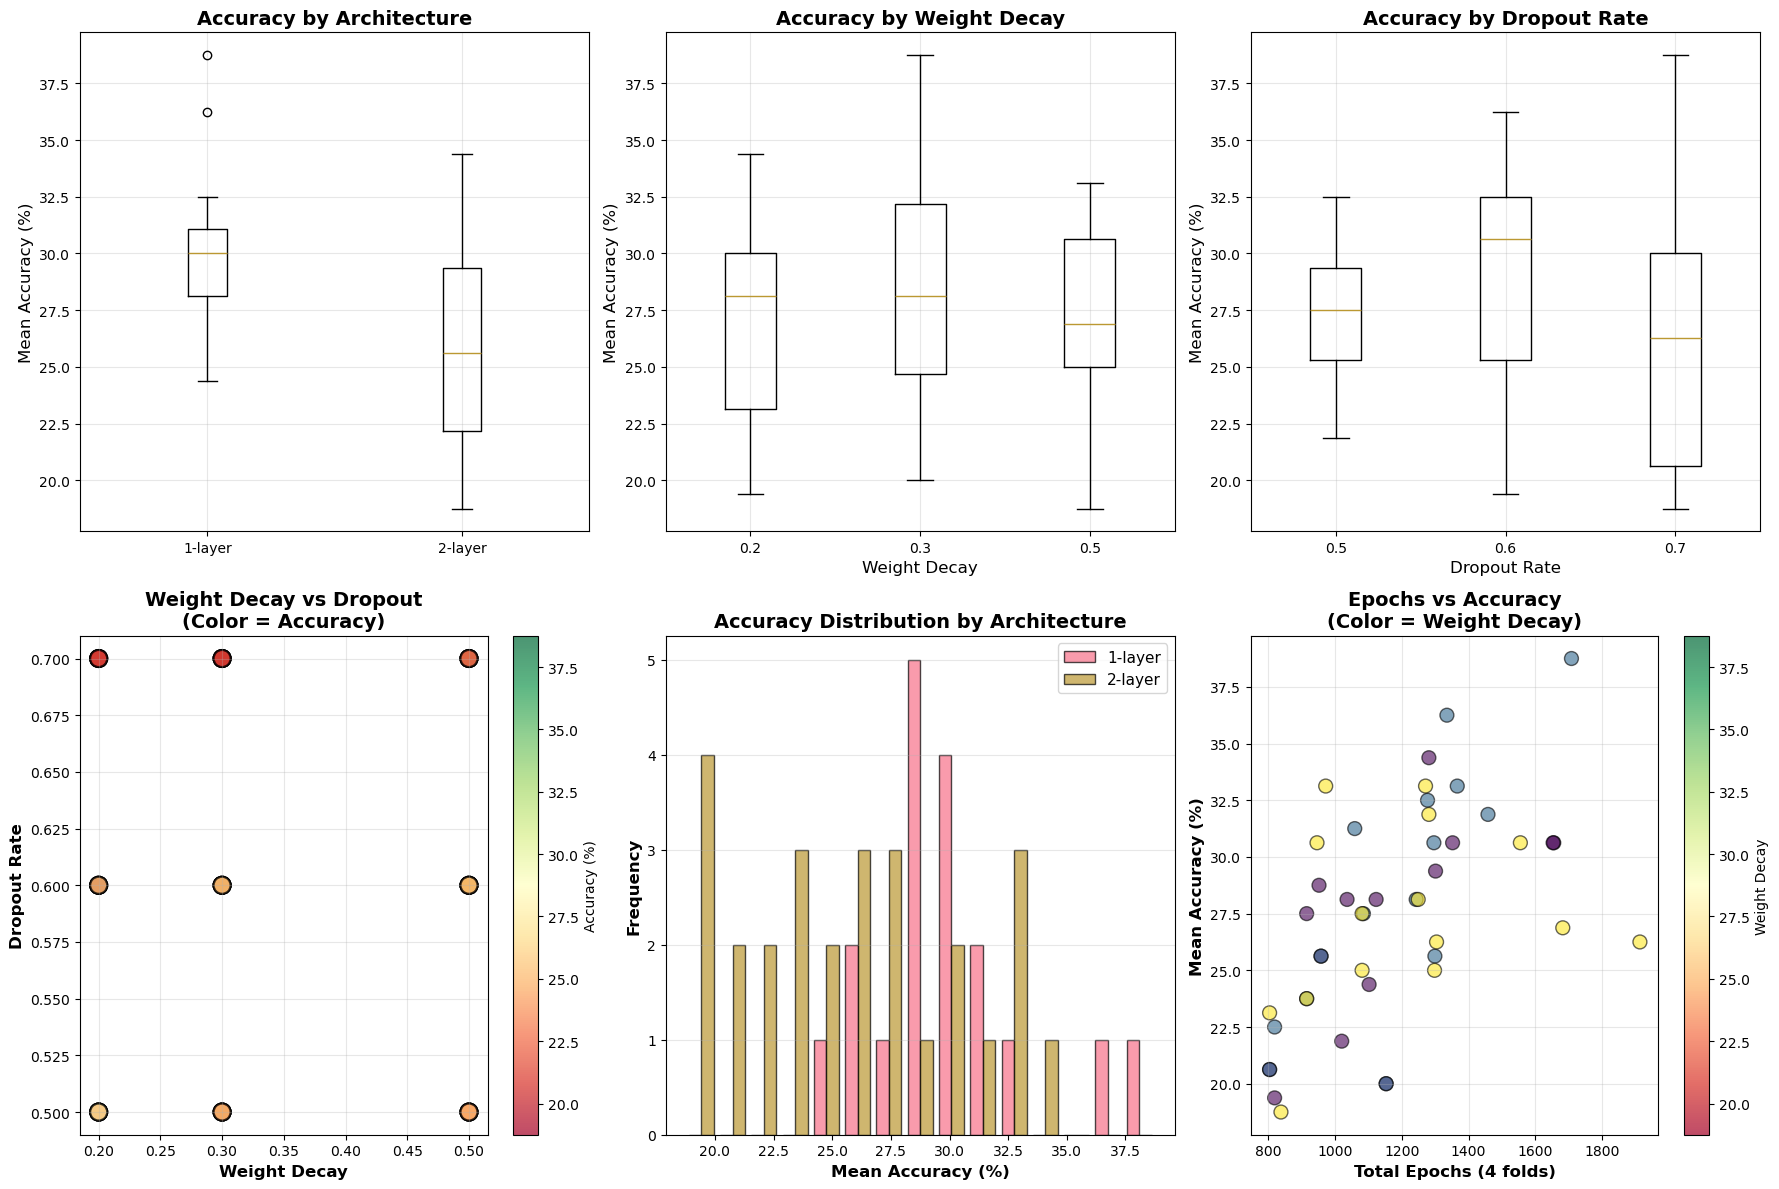

Overview plot saved to: results\4_Classes_ANN\figures\model_comparison_overview.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

df['mean_acc_pct'] = df['mean_accuracy'] * 100

axes[0, 0].boxplot([df[df['architecture'] == arch]['mean_acc_pct'].values 
                     for arch in df['architecture'].unique()],
                    labels=df['architecture'].unique())
axes[0, 0].set_title('Accuracy by Architecture', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Mean Accuracy (%)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot([df[df['weight_decay'] == wd]['mean_acc_pct'].values 
                     for wd in sorted(df['weight_decay'].unique())],
                    labels=sorted(df['weight_decay'].unique()))
axes[0, 1].set_title('Accuracy by Weight Decay', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Weight Decay', fontsize=12)
axes[0, 1].set_ylabel('Mean Accuracy (%)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].boxplot([df[df['dropout_rate'] == dr]['mean_acc_pct'].values 
                     for dr in sorted(df['dropout_rate'].unique())],
                    labels=sorted(df['dropout_rate'].unique()))
axes[0, 2].set_title('Accuracy by Dropout Rate', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Dropout Rate', fontsize=12)
axes[0, 2].set_ylabel('Mean Accuracy (%)', fontsize=12)
axes[0, 2].grid(True, alpha=0.3)

scatter = axes[1, 0].scatter(df['weight_decay'], df['dropout_rate'], 
                             c=df['mean_acc_pct'], cmap='RdYlGn', 
                             s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
axes[1, 0].set_xlabel('Weight Decay', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Dropout Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Weight Decay vs Dropout\n(Color = Accuracy)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 0], label='Accuracy (%)')
axes[1, 0].grid(True, alpha=0.3)

single_layer = df[df['architecture'] == '1-layer']
two_layer = df[df['architecture'] == '2-layer']
axes[1, 1].hist([single_layer['mean_acc_pct'], two_layer['mean_acc_pct']], 
                bins=15, label=['1-layer', '2-layer'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Mean Accuracy (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Accuracy Distribution by Architecture', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[1, 2].scatter(df['total_epochs'], df['mean_acc_pct'], 
                   c=df['weight_decay'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
axes[1, 2].set_xlabel('Total Epochs (4 folds)', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Mean Accuracy (%)', fontsize=12, fontweight='bold')
axes[1, 2].set_title('Epochs vs Accuracy\n(Color = Weight Decay)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 2], label='Weight Decay')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'model_comparison_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Overview plot saved to: {RESULTS_DIR / 'figures' / 'model_comparison_overview.png'}")

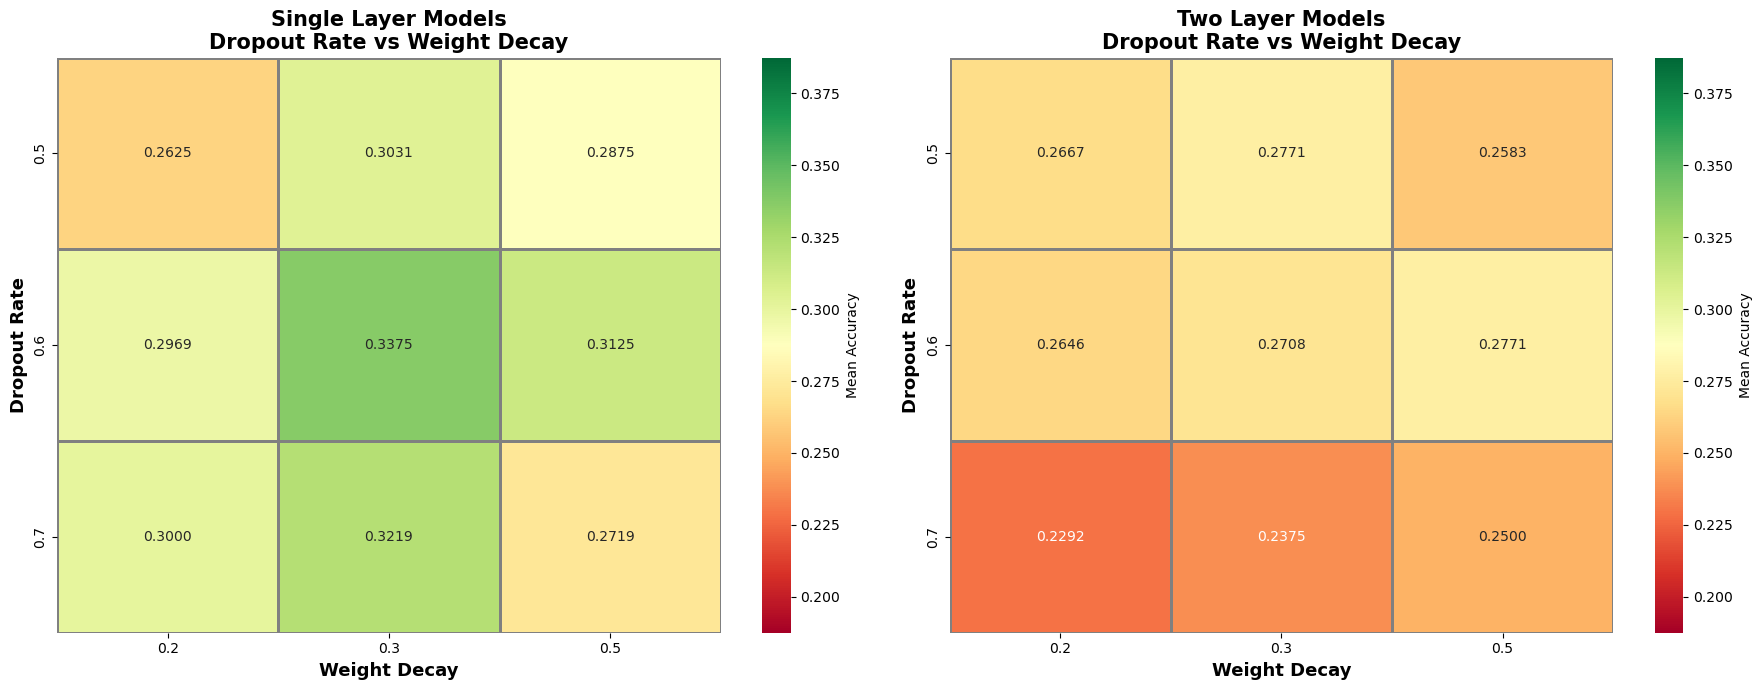

Heatmaps saved to: results\4_Classes_ANN\figures\heatmaps_dropout_weightdecay.png


In [7]:
single_layer_df = df[df['architecture'] == '1-layer']
two_layer_df = df[df['architecture'] == '2-layer']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if len(single_layer_df) > 0:
    pivot1 = single_layer_df.pivot_table(
        values='mean_accuracy', 
        index='dropout_rate', 
        columns='weight_decay',
        aggfunc='mean'
    )
    sns.heatmap(pivot1, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[0], 
                vmin=df['mean_accuracy'].min(), vmax=df['mean_accuracy'].max(),
                cbar_kws={'label': 'Mean Accuracy'}, linewidths=1, linecolor='gray')
    axes[0].set_title('Single Layer Models\nDropout Rate vs Weight Decay', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Weight Decay', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Dropout Rate', fontsize=13, fontweight='bold')

if len(two_layer_df) > 0:
    pivot2 = two_layer_df.pivot_table(
        values='mean_accuracy', 
        index='dropout_rate', 
        columns='weight_decay',
        aggfunc='mean'
    )
    sns.heatmap(pivot2, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[1],
                vmin=df['mean_accuracy'].min(), vmax=df['mean_accuracy'].max(),
                cbar_kws={'label': 'Mean Accuracy'}, linewidths=1, linecolor='gray')
    axes[1].set_title('Two Layer Models\nDropout Rate vs Weight Decay', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Weight Decay', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Dropout Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'heatmaps_dropout_weightdecay.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Heatmaps saved to: {RESULTS_DIR / 'figures' / 'heatmaps_dropout_weightdecay.png'}")

In [8]:
print("="*100)
print("DETAILED ARCHITECTURE COMPARISON")
print("="*100)

for arch in df['architecture'].unique():
    arch_df = df[df['architecture'] == arch].sort_values('mean_accuracy', ascending=False)
    
    print(f"\n{arch.upper()}:")
    print(f"  Total models: {len(arch_df)}")
    print(f"  Best accuracy: {arch_df['mean_accuracy'].max()*100:.2f}%")
    print(f"  Worst accuracy: {arch_df['mean_accuracy'].min()*100:.2f}%")
    print(f"  Mean accuracy: {arch_df['mean_accuracy'].mean()*100:.2f}%")
    print(f"  Std accuracy: {arch_df['mean_accuracy'].std()*100:.2f}%")
    
    print(f"\n  Top 3 configurations:")
    for i, (_, row) in enumerate(arch_df.head(3).iterrows(), 1):
        hidden_str = f"{row['hidden1']}" if row['hidden2'] == 'None' else f"{row['hidden1']}-{row['hidden2']}"
        print(f"    {i}. h={hidden_str}, wd={row['weight_decay']}, dr={row['dropout_rate']} → {row['mean_accuracy']*100:.2f}%")

print("\n" + "="*100)

DETAILED ARCHITECTURE COMPARISON

1-LAYER:
  Total models: 18
  Best accuracy: 38.75%
  Worst accuracy: 24.38%
  Mean accuracy: 29.93%
  Std accuracy: 3.56%

  Top 3 configurations:
    1. h=16-nan, wd=0.3, dr=0.7 → 38.75%
    2. h=16-nan, wd=0.3, dr=0.6 → 36.25%
    3. h=8-nan, wd=0.3, dr=0.5 → 32.50%

2-LAYER:
  Total models: 27
  Best accuracy: 34.38%
  Worst accuracy: 18.75%
  Mean accuracy: 25.90%
  Std accuracy: 4.75%

  Top 3 configurations:
    1. h=32-16.0, wd=0.2, dr=0.6 → 34.38%
    2. h=32-16.0, wd=0.3, dr=0.6 → 33.12%
    3. h=32-16.0, wd=0.5, dr=0.6 → 33.12%



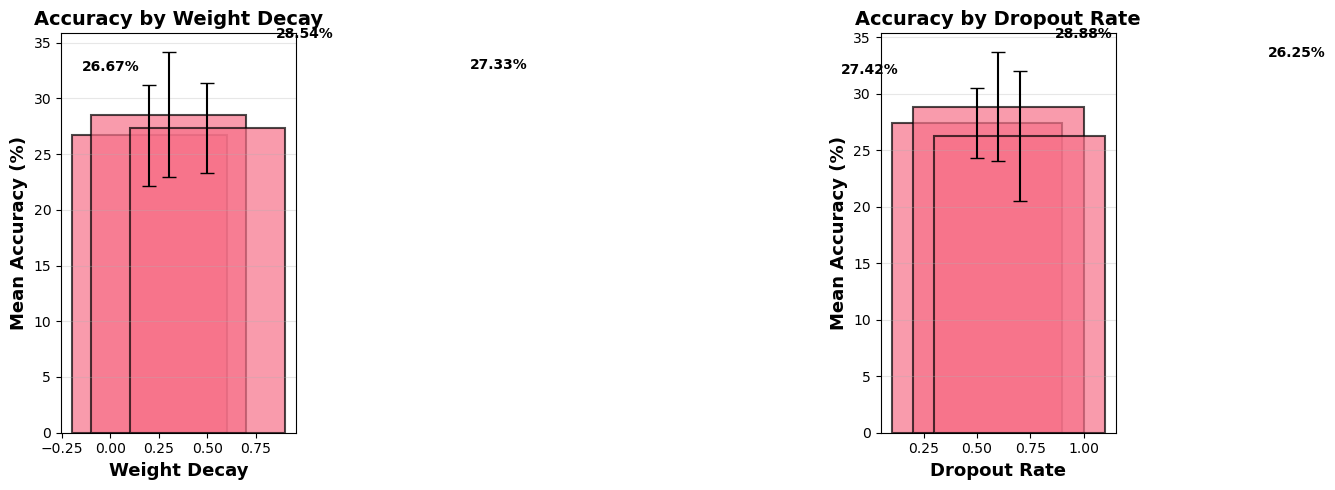

Hyperparameter impact plot saved to: results\4_Classes_ANN\figures\hyperparameter_impact.png


In [9]:
params = ['weight_decay', 'dropout_rate']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, param in enumerate(params):
    param_means = df.groupby(param)['mean_accuracy'].agg(['mean', 'std', 'count'])
    param_means = param_means.sort_index()
    
    x = param_means.index
    y = param_means['mean'] * 100
    yerr = param_means['std'] * 100
    
    axes[idx].bar(x, y, yerr=yerr, capsize=5, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_xlabel(param.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Mean Accuracy (%)', fontsize=13, fontweight='bold')
    axes[idx].set_title(f'Accuracy by {param.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, (val, acc) in enumerate(zip(x, y)):
        axes[idx].text(i, acc + yerr.iloc[i] + 1, f'{acc:.2f}%', 
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'hyperparameter_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Hyperparameter impact plot saved to: {RESULTS_DIR / 'figures' / 'hyperparameter_impact.png'}")

In [10]:
print("="*100)
print("BEST CONFIGURATION PER ARCHITECTURE")
print("="*100)

for arch in df['architecture'].unique():
    arch_df = df[df['architecture'] == arch]
    best_model = arch_df.loc[arch_df['mean_accuracy'].idxmax()]
    
    print(f"\n{arch.upper()}:")
    print(f"  Experiment ID: {best_model['experiment_id']}")
    print(f"  Hidden layers: {best_model['hidden1']}" + (f" → {best_model['hidden2']}" if best_model['hidden2'] != 'None' else ""))
    print(f"  Weight Decay: {best_model['weight_decay']}")
    print(f"  Dropout Rate: {best_model['dropout_rate']}")
    print(f"  Accuracy: {best_model['mean_accuracy']*100:.2f}% ± {best_model['std_accuracy']*100:.2f}%")
    print(f"  Model file: {best_model['model_file']}")

BEST CONFIGURATION PER ARCHITECTURE

1-LAYER:
  Experiment ID: 6
  Hidden layers: 16 → nan
  Weight Decay: 0.3
  Dropout Rate: 0.7
  Accuracy: 38.75% ± 5.73%
  Model file: model_h16_wd0.3_dr0.7.pt

2-LAYER:
  Experiment ID: 20
  Hidden layers: 32 → 16.0
  Weight Decay: 0.2
  Dropout Rate: 0.6
  Accuracy: 34.38% ± 4.80%
  Model file: model_h32-16_wd0.2_dr0.6.pt


In [11]:
from scipy import stats

single = df[df['architecture'] == '1-layer']['mean_accuracy']
two = df[df['architecture'] == '2-layer']['mean_accuracy']

t_stat, p_value = stats.ttest_ind(single, two)

print("="*80)
print("STATISTICAL COMPARISON: 1-LAYER vs 2-LAYER")
print("="*80)
print(f"1-layer mean: {single.mean()*100:.2f}% (n={len(single)})")
print(f"2-layer mean: {two.mean()*100:.2f}% (n={len(two)})")
print(f"Difference: {(two.mean() - single.mean())*100:.2f}%")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"\n✓ Statistically significant difference (p < 0.05)")
else:
    print(f"\n✗ No statistically significant difference (p >= 0.05)")

STATISTICAL COMPARISON: 1-LAYER vs 2-LAYER
1-layer mean: 29.93% (n=18)
2-layer mean: 25.90% (n=27)
Difference: -4.03%

T-statistic: 3.0640
P-value: 0.0038

✓ Statistically significant difference (p < 0.05)


In [12]:
summary_report = {
    'total_experiments': len(df),
    'best_accuracy': df['mean_accuracy'].max(),
    'worst_accuracy': df['mean_accuracy'].min(),
    'mean_accuracy': df['mean_accuracy'].mean(),
    'best_model_id': df_sorted.iloc[0]['experiment_id'],
    'best_architecture': df_sorted.iloc[0]['architecture'],
    'best_hidden1': df_sorted.iloc[0]['hidden1'],
    'best_hidden2': df_sorted.iloc[0]['hidden2'],
    'best_weight_decay': df_sorted.iloc[0]['weight_decay'],
    'best_dropout': df_sorted.iloc[0]['dropout_rate'],
    'best_model_file': df_sorted.iloc[0]['model_file']
}

summary_df = pd.DataFrame([summary_report])
summary_df.to_csv(RESULTS_DIR / 'summary_report.csv', index=False)

print("Summary report saved to:", RESULTS_DIR / 'summary_report.csv')
print("\nSummary:")
for key, value in summary_report.items():
    print(f"  {key}: {value}")

Summary report saved to: results\4_Classes_ANN\summary_report.csv

Summary:
  total_experiments: 45
  best_accuracy: 0.3874999999999999
  worst_accuracy: 0.1875
  mean_accuracy: 0.2751388888888889
  best_model_id: 6
  best_architecture: 1-layer
  best_hidden1: 16
  best_hidden2: nan
  best_weight_decay: 0.3
  best_dropout: 0.7
  best_model_file: model_h16_wd0.3_dr0.7.pt
